# Deep Learning Assignment 2026 — Starting Code

## Loading Dataset

You can download the dataset from
https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images

The Lung and Colon Cancer Histopathological Image Dataset (LC25000) consists of 25,000
histopathological images from 5 classes, with 5,000 images per class:

| Folder | Class |
| --- | --- |
| `colon_aca` | Colon adenocarcinoma |
| `colon_n` | Benign colonic tissue |
| `lung_aca` | Lung adenocarcinoma |
| `lung_n` | Benign lung tissue |
| `lung_scc` | Lung squamous cell carcinoma |

The cells below download the dataset, read all 25,000 images and resize them from
768 x 768 to **120 x 120**.

**Before you start:** Runtime -> Change runtime type -> **T4 GPU**. On a CPU runtime the
models in this assignment take many times longer to train.

### Step 1 — Download the dataset

`kagglehub` downloads the dataset and returns the path to it. You need a free Kaggle
account. If you are asked to authenticate, go to your Kaggle account page
(**Settings -> API -> Create New Token**), which downloads a `kaggle.json` file containing
your username and key, and enter those when prompted.

The first run downloads about 1.9 GB. Later runs reuse the cached copy.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
print("Path to dataset files:", path)

C:\Users\bramf\PycharmProjects\Lung-and-Colon-Cancer-Classification2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.76G/1.76G [00:53<00:00, 35.0MB/s]

Extracting files...


Path to dataset files: C:\Users\bramf\.cache\kagglehub\datasets\andrewmvd\lung-and-colon-cancer-histopathological-images\versions\1


### Step 2 — Check the folder structure

Run this before the loading step. If the paths are wrong you will see it here immediately,
rather than after 25,000 error messages.

In [7]:
import os

root = os.path.join(path, "lung_colon_image_set")

for r, dirs, fnames in os.walk(root):
    depth = r.replace(path, "").count(os.sep)
    print("  " * depth + os.path.basename(r) + f"  ({len(fnames)} files)")

  lung_colon_image_set  (0 files)
    colon_image_sets  (0 files)
      colon_aca  (5000 files)
      colon_n  (5000 files)
    lung_image_sets  (0 files)
      lung_aca  (5000 files)
      lung_n  (5000 files)
      lung_scc  (5000 files)


### Step 3 — Load and resize the images

This takes a few minutes. Three things keep it as fast as possible:

* `Image.draft()` makes the JPEG decoder work at 192 x 192 instead of 768 x 768, skipping
  most of the decode cost before any resizing happens.
* A thread pool — PIL releases the GIL while decoding, so this actually parallelises.
* The output array is preallocated, so there is no build-a-list-then-copy step.

The result is cached to `/content`, so restarting the kernel does not cost you the whole
loop again.

The images are kept as `uint8` (values 0-255) on purpose: the full array is about 1.1 GB in
`uint8` but would be 4.3 GB as `float32`. Keras casts each batch to float automatically
during training, so you do not need to convert the whole array yourself.

In [8]:
from pathlib import Path

cwd = os.getcwd()
data_dir = os.path.abspath(os.path.join(cwd, os.pardir))
content_dir = Path(data_dir) / "data/content"
content_dir.mkdir(parents=True, exist_ok=True)

print(content_dir)

C:\Users\bramf\PycharmProjects\Lung-and-Colon-Cancer-Classification2\data\content


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

# CACHE = "/content/lc25000_120.npz"
CACHE = Path(content_dir) / "lc25000_120.npz"
IMG_SIZE = (120, 120)

# Relative path of each class directory inside the dataset
class_dirs = {
    "colon_aca": "colon_image_sets/colon_aca",
    "colon_n":   "colon_image_sets/colon_n",
    "lung_aca":  "lung_image_sets/lung_aca",
    "lung_n":    "lung_image_sets/lung_n",
    "lung_scc":  "lung_image_sets/lung_scc",
}

if os.path.exists(CACHE):
    z = np.load(CACHE, allow_pickle=True)
    data, class_labels = z["data"], z["labels"]
    print("loaded from cache")
else:
    # Collect the file list first, so we can preallocate and parallelise
    files, labels = [], []
    for class_name, rel_path in class_dirs.items():
        class_path = os.path.join(root, rel_path)
        names = sorted(f for f in os.listdir(class_path)
                       if f.lower().endswith((".jpeg", ".jpg")))
        print(f"{class_name}: {len(names)} files")
        files += [os.path.join(class_path, n) for n in names]
        labels += [class_name] * len(names)

    data = np.zeros((len(files), *IMG_SIZE, 3), dtype=np.uint8)

    def load(i):
        with Image.open(files[i]) as image:
            image.draft("RGB", IMG_SIZE)     # decode at 192x192 instead of 768x768
            data[i] = np.asarray(image.convert("RGB").resize(IMG_SIZE, Image.LANCZOS))

    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(load, range(len(files))), total=len(files), desc="loading"))

    class_labels = np.array(labels)
    np.savez(CACHE, data=data, labels=class_labels)
    print("cached to", CACHE)

print(data.shape, data.dtype)
print(np.unique(class_labels, return_counts=True))

colon_aca: 5000 files
colon_n: 5000 files
lung_aca: 5000 files
lung_n: 5000 files
lung_scc: 5000 files


loading: 100%|██████████| 25000/25000 [00:29<00:00, 859.32it/s]


cached to C:\Users\bramf\PycharmProjects\Lung-and-Colon-Cancer-Classification2\data\content\lc25000_120.npz
(25000, 120, 120, 3) uint8
(array(['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc'],
      dtype='<U9'), array([5000, 5000, 5000, 5000, 5000], dtype=int64))


### Optional — keep a copy on your Google Drive

The Colab disk is wiped when your runtime is deleted. Running this cell saves the arrays to
your Drive so you can reload them in a later session without repeating Steps 1-3.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
#
# save_folder = "/content/drive/MyDrive/Deep_Learning_2026/Assignment/"
# os.makedirs(save_folder, exist_ok=True)
# np.save(save_folder + "data.npy", data)
# np.save(save_folder + "labels_name.npy", class_labels)
#
# # ...and to load them again in a later session:
# # data = np.load(save_folder + "data.npy")
# # class_labels = np.load(save_folder + "labels_name.npy")

---
## Preprocessing

Convert the target values using the proper function for one-hot encoding, and create
train, validation and test sets using stratified train-test splits with proportions of
60% / 20% / 20% and a random seed of 42.

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# One-hot encode the string labels directly
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(class_labels.reshape(-1, 1))

print("category", encoder.categories_[0])

# Split into 60% training data and 40% temporary data
# Split the original labels as well for stratification in the next split
X_train, X_temp, y_train, y_temp, labels_train, labels_temp = train_test_split(data,y,class_labels,test_size=0.4,random_state=42,stratify=class_labels)

# Split the temporary data equally into 20% validation and 20% test data
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42,stratify=labels_temp )

del X_temp

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

category ['colon_aca' 'colon_n' 'lung_aca' 'lung_n' 'lung_scc']
Train: (15000, 120, 120, 3) (15000, 5)
Validation: (5000, 120, 120, 3) (5000, 5)
Test: (5000, 120, 120, 3) (5000, 5)


## Visualizing Sample Images

Randomly select 15 samples and display each image with its label as text on top of the
image, arranged in a single figure.

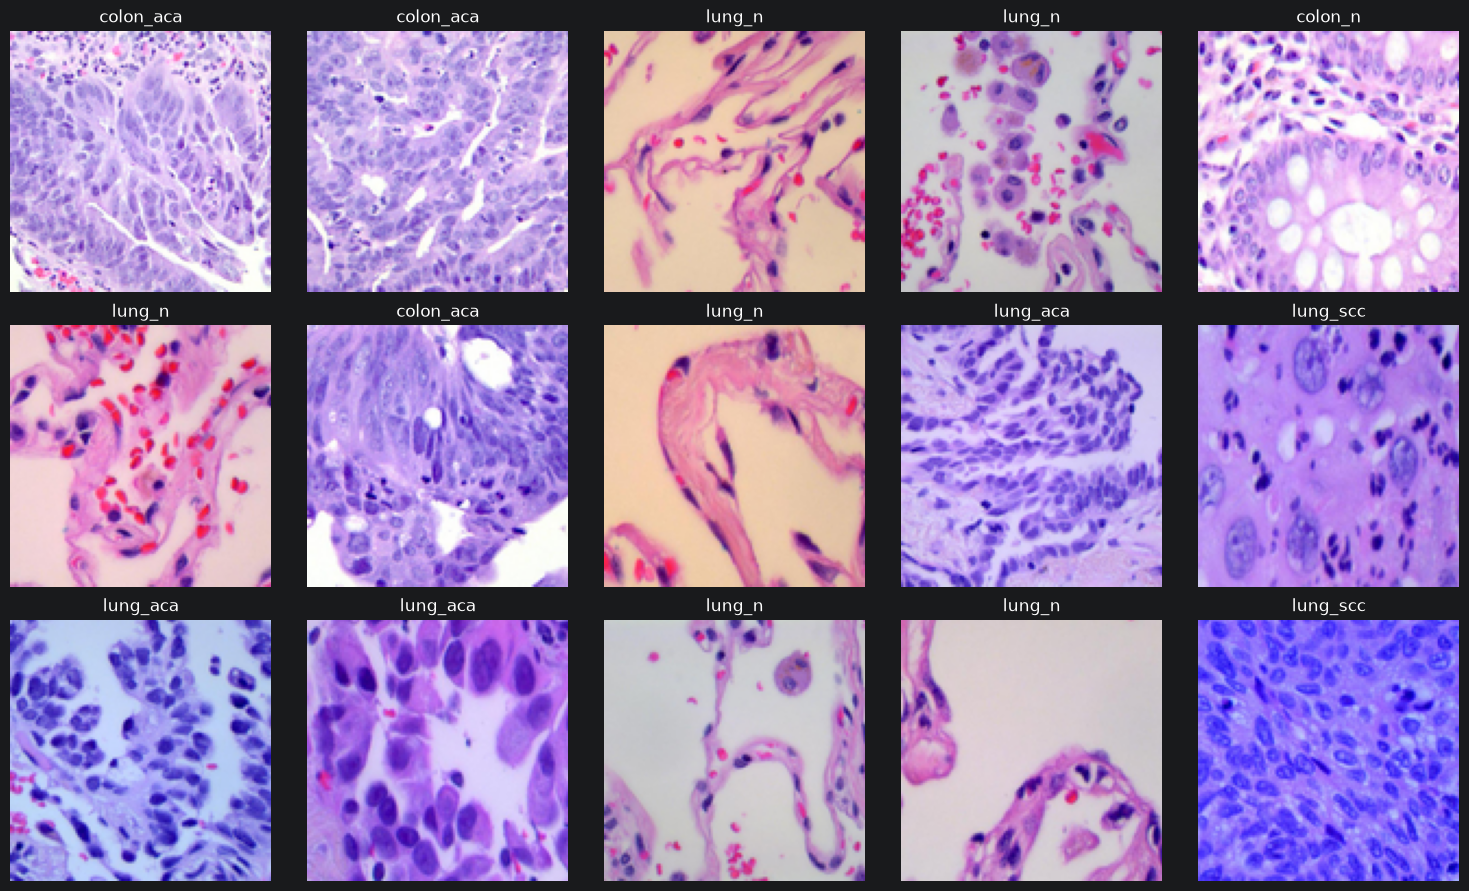

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Randomly select 15 images without replacement
rng = np.random.default_rng(42)
indices = rng.choice(len(data), size=15, replace=False)

plt.figure(figsize=(15, 9))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(data[indices[i]])
    plt.title(class_labels[indices[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Visualize Class Label Distribution

Create a bar plot showing how many samples the dataset has for each class.

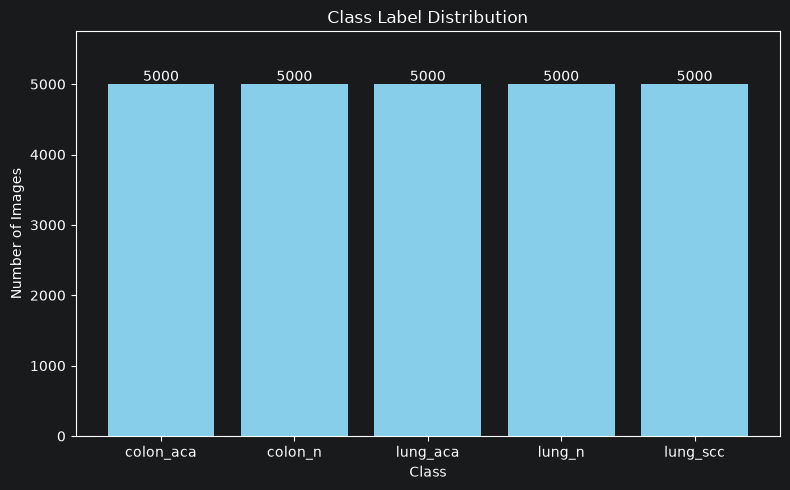

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Count the number of images in each class
classes, counts = np.unique(class_labels, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color="skyblue")
plt.title("Class Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.ylim(0, counts.max() * 1.15)

# Display the count above each bar
for i in range(len(classes)):
    plt.text(i, counts[i], str(counts[i]), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Baseline Model

Implement the baseline CNN exactly as described in the assignment, train it for 15 epochs
with a batch size of 32, and analyse its performance (accuracy/loss curves, ROC curve with
AUC, confusion matrix, and performance measures for the validation and test sets).

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, models, regularizers
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

keras.utils.set_random_seed(42)
class_names = np.asarray(encoder.categories_[0])
num_classes = len(class_names)

In [17]:
def build_baseline():
    # Match the architecture in Figure 2 without extra preprocessing layers.
    model = models.Sequential([
        layers.Input(shape=(120, 120, 3)),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="baseline")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

In [18]:
baseline_model = build_baseline()
baseline_model.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 120, 120, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,309 (3.73 MB)

 Trainable params: 978,309 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, batch_size=32, shuffle=True, verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 142ms/step - accuracy: 0.6876 - loss: 1.9227 - val_accuracy: 0.7266 - val_loss: 0.6131
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - accuracy: 0.8115 - loss: 0.4665 - val_accuracy: 0.7468 - val_loss: 0.5967
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - accuracy: 0.8473 - loss: 0.3721 - val_accuracy: 0.8572 - val_loss: 0.3713
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 146ms/step - accuracy: 0.8737 - loss: 0.3189 - val_accuracy: 0.8744 - val_loss: 0.3282
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - accuracy: 0.9051 - loss: 0.2467 - val_accuracy: 0.8890 - val_loss: 0.3193
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - accuracy: 0.9165 - loss: 0.2257 - val_accuracy: 0.9036 - val_loss: 0.2807
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - accuracy: 0.9212 - loss: 0.2081 - val_accuracy: 0.9142 - val_loss: 0.3265
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - accuracy: 0.9373 - loss: 0

## Enhanced Model

Adapt the baseline by intentionally tweaking at least six different hyperparameters, and
compare the results against the baseline.

In [33]:
def build_l2_model(l2_val=1e-4):
    """
    Constructs a baseline-identical CNN with L2 regularization
    on trainable convolutional and dense kernels to optimize generalization and minimize loss.
    """
    reg = regularizers.l2(l2_val)

    model = models.Sequential([
        layers.Input(shape=(120, 120, 3)),

        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),

        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),

        # Convolutional Block 3
        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=reg),
        layers.MaxPooling2D((2, 2)),

        # Dense / Fully Connected Layers
        layers.Flatten(),
        layers.Dense(64, activation="relu", kernel_regularizer=reg),
        layers.Dense(num_classes, activation="softmax")
    ], name="baseline_l2_regularized")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

enhanced_model = build_l2_model(l2_val=1e-4)
enhanced_model.summary()

Model: "baseline_l2_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 120, 120, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,309 (3.73 MB)

 Trainable params: 978,309 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
enhanced_history = enhanced_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    shuffle=True,
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 149ms/step - accuracy: 0.5823 - loss: 3.2402 - val_accuracy: 0.7614 - val_loss: 0.5726
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 147ms/step - accuracy: 0.7495 - loss: 0.5772 - val_accuracy: 0.7864 - val_loss: 0.4997
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 142ms/step - accuracy: 0.8068 - loss: 0.4524 - val_accuracy: 0.8414 - val_loss: 0.4071
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 146ms/step - accuracy: 0.8535 - loss: 0.3660 - val_accuracy: 0.8878 - val_loss: 0.3015
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 142ms/step - accuracy: 0.8887 - loss: 0.2951 - val_accuracy: 0.8570 - val_loss: 0.4599
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - accuracy: 0.9207 - loss: 0.2249 - val_accuracy: 0.9114 - val_loss: 0.2682
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - accuracy: 0.9299 - loss: 0.2055 - val_accuracy: 0.9256 - val_loss: 0.2286
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - accuracy: 0.9331 - loss: 0

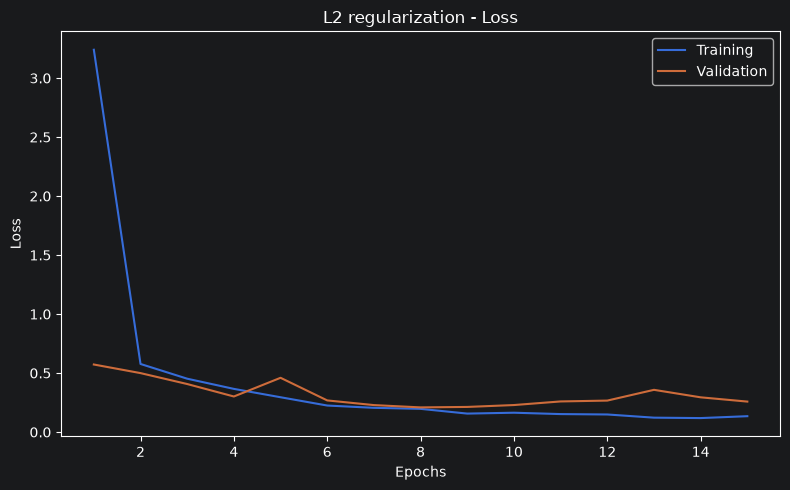

In [35]:
plt.figure(figsize=(8, 5))
epochs = range(1, len(enhanced_history.history['loss']) + 1)
plt.plot(epochs, enhanced_history.history['loss'], label='Training')
plt.plot(epochs, enhanced_history.history['val_loss'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('L2 regularization - Loss')
plt.legend()
plt.tight_layout()
plt.show()

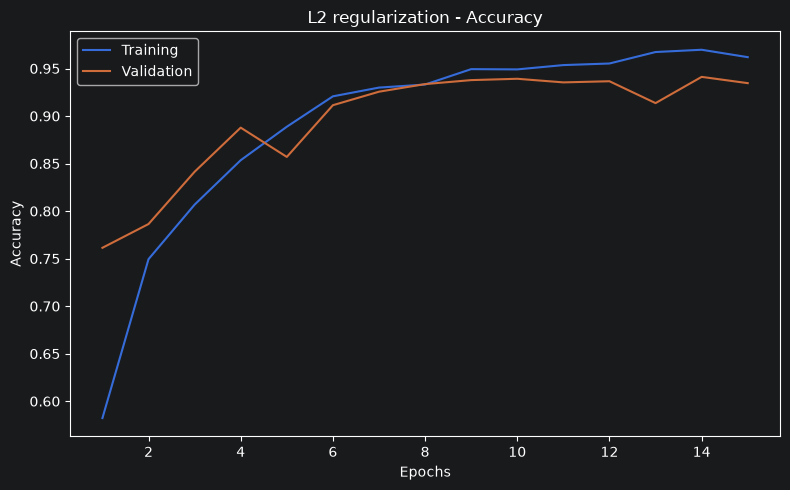

In [36]:
plt.figure(figsize=(8, 5))
epochs = range(1, len(enhanced_history.history['accuracy']) + 1)
plt.plot(epochs, enhanced_history.history['accuracy'], label='Training')
plt.plot(epochs, enhanced_history.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('L2 regularization - Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
l2_probabilities = enhanced_model.predict(X_val, batch_size=32, verbose=0)
l2_pred = l2_probabilities.argmax(axis=1)
l2_true = y_val.argmax(axis=1)
print('L2 regularization - Validation')
print(classification_report(
    l2_true, l2_pred,
    labels=range(num_classes), target_names=class_names,
    digits=4, zero_division=0
))

L2 regularization - Validation
              precision    recall  f1-score   support

   colon_aca     0.9206    0.9850    0.9517      1000
     colon_n     0.9862    0.9270    0.9557      1000
    lung_aca     0.9100    0.8490    0.8784      1000
      lung_n     0.9879    0.9780    0.9829      1000
    lung_scc     0.8754    0.9340    0.9037      1000

    accuracy                         0.9346      5000
   macro avg     0.9360    0.9346    0.9345      5000
weighted avg     0.9360    0.9346    0.9345      5000



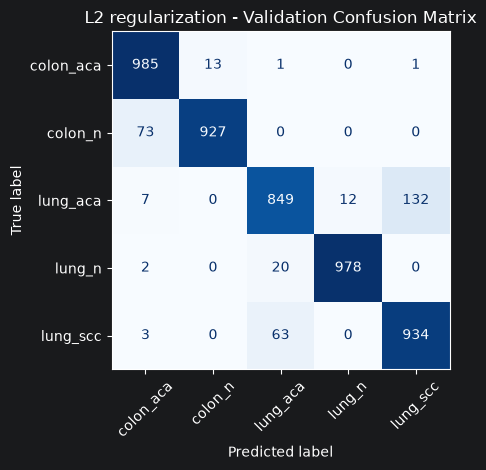

In [38]:
ConfusionMatrixDisplay.from_predictions(
    l2_true, l2_pred,
    labels=range(num_classes), display_labels=class_names,
    cmap='Blues', xticks_rotation=45, colorbar=False
)
plt.title('L2 regularization - Validation Confusion Matrix')
plt.tight_layout()
plt.show()

In [47]:
def build_dropout_model(dense_dropout=0.5):
    """
    Constructs a baseline-identical CNN regularized with input rescaling
    and dense-layer dropout to maximize generalization without risk of gradient starvation.
    """
    model = models.Sequential([
        layers.Input(shape=(120, 120, 3)),
        layers.Rescaling(1.0 / 255),  # Normalizes inputs to [0, 1] to prevent dying ReLUs

        # Convolutional Block 1 (keeps low-level feature extraction intact)
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Convolutional Block 3
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Dense / Fully Connected Layers
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dense_dropout),  # Targeted regularization on the parameter-heavy dense layer
        layers.Dense(num_classes, activation="softmax")
    ], name="baseline_dropout_stabilized")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

enhanced_model_dropout = build_dropout_model(dense_dropout=0.5)
enhanced_model_dropout.summary()

Model: "baseline_dropout_stabilized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 120, 120, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,309 (3.73 MB)

 Trainable params: 978,309 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
enhanced_history_dropout = enhanced_model_dropout.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    shuffle=True,
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 139ms/step - accuracy: 0.5573 - loss: 0.9080 - val_accuracy: 0.7042 - val_loss: 0.6613
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - accuracy: 0.6994 - loss: 0.6544 - val_accuracy: 0.8434 - val_loss: 0.4189
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - accuracy: 0.7707 - loss: 0.5155 - val_accuracy: 0.8926 - val_loss: 0.2905
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 150ms/step - accuracy: 0.8382 - loss: 0.4037 - val_accuracy: 0.9148 - val_loss: 0.2354
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.8807 - loss: 0.3149 - val_accuracy: 0.9324 - val_loss: 0.1838
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - accuracy: 0.9032 - loss: 0.2576 - val_accuracy: 0.9394 - val_loss: 0.1752
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 150ms/step - accuracy: 0.9155 - loss: 0.2249 - val_accuracy: 0.9442 - val_loss: 0.1650
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 142ms/step - accuracy: 0.9307 - loss: 0

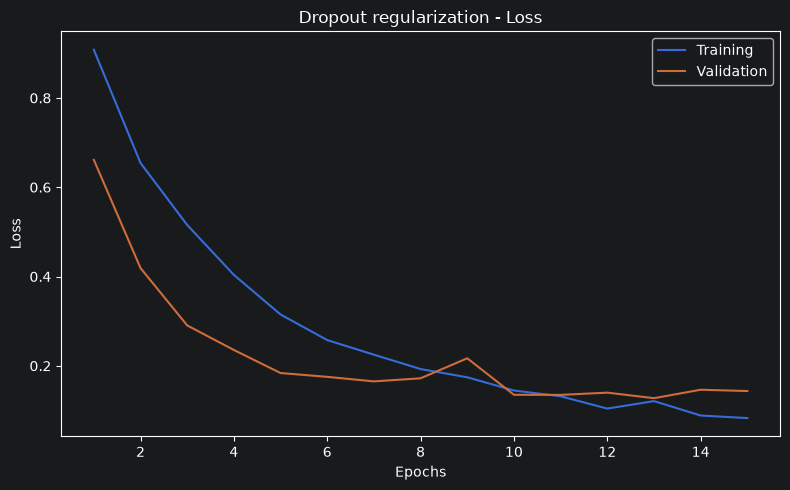

In [49]:
plt.figure(figsize=(8, 5))
epochs = range(1, len(enhanced_history_dropout.history['loss']) + 1)
plt.plot(epochs, enhanced_history_dropout.history['loss'], label='Training')
plt.plot(epochs, enhanced_history_dropout.history['val_loss'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Dropout regularization - Loss')
plt.legend()
plt.tight_layout()
plt.show()

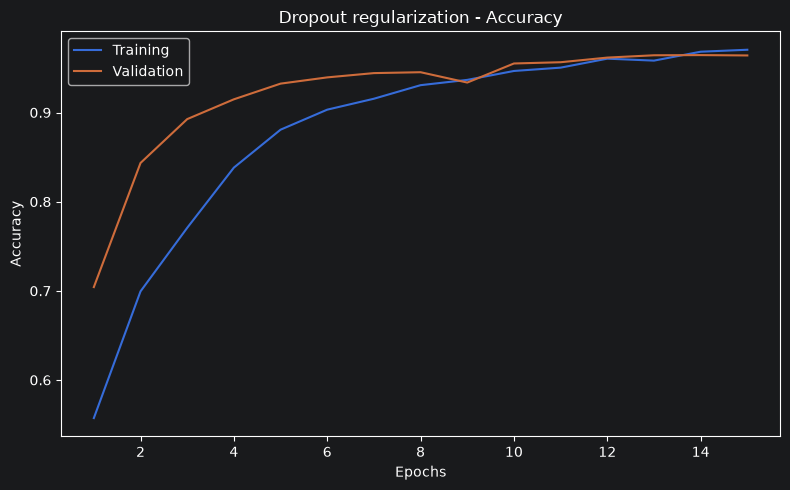

In [50]:
plt.figure(figsize=(8, 5))
epochs = range(1, len(enhanced_history_dropout.history['accuracy']) + 1)
plt.plot(epochs, enhanced_history_dropout.history['accuracy'], label='Training')
plt.plot(epochs, enhanced_history_dropout.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Dropout regularization - Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
dropout_probabilities = enhanced_model_dropout.predict(X_val, batch_size=32, verbose=0)
dropout_pred = dropout_probabilities.argmax(axis=1)
dropout_true = y_val.argmax(axis=1)
print('Dropout regularization - Validation')
print(classification_report(
    dropout_pred, dropout_true,
    labels=range(num_classes), target_names=class_names,
    digits=4, zero_division=0
))

Dropout regularization - Validation
              precision    recall  f1-score   support

   colon_aca     0.9860    0.9601    0.9729      1027
     colon_n     0.9610    0.9897    0.9751       971
    lung_aca     0.9330    0.9377    0.9353       995
      lung_n     0.9950    0.9950    0.9950      1000
    lung_scc     0.9450    0.9384    0.9417      1007

    accuracy                         0.9640      5000
   macro avg     0.9640    0.9642    0.9640      5000
weighted avg     0.9641    0.9640    0.9640      5000



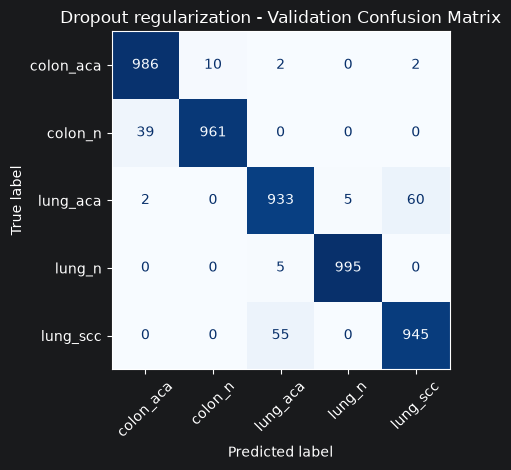

In [52]:
ConfusionMatrixDisplay.from_predictions(
    dropout_true, dropout_pred,
    labels=range(num_classes), display_labels=class_names,
    cmap='Blues', xticks_rotation=45, colorbar=False
)
plt.title('Dropout regularization - Validation Confusion Matrix')
plt.tight_layout()
plt.show()

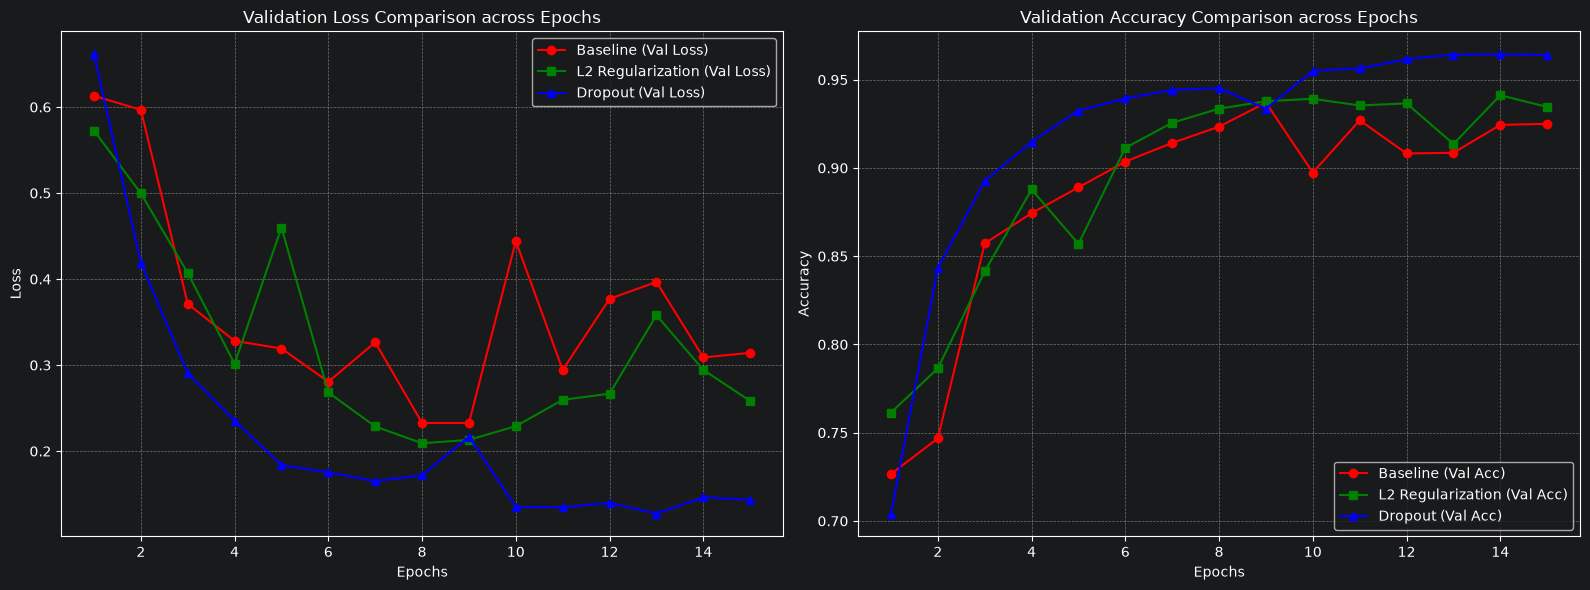

In [53]:
epochs = range(1, 16)

plt.figure(figsize=(16, 6))

# Subplot 1: Validation Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(epochs, baseline_history.history['val_loss'], 'r-o', label='Baseline (Val Loss)')
plt.plot(epochs, enhanced_history.history['val_loss'], 'g-s', label='L2 Regularization (Val Loss)')
plt.plot(epochs, enhanced_history_dropout.history['val_loss'], 'b-^', label='Dropout (Val Loss)')
plt.title('Validation Loss Comparison across Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Validation Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(epochs, baseline_history.history['val_accuracy'], 'r-o', label='Baseline (Val Acc)')
plt.plot(epochs, enhanced_history.history['val_accuracy'], 'g-s', label='L2 Regularization (Val Acc)')
plt.plot(epochs, enhanced_history_dropout.history['val_accuracy'], 'b-^', label='Dropout (Val Acc)')
plt.title('Validation Accuracy Comparison across Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [54]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

models_dict = {
    "Baseline": (baseline_model, baseline_history),
    "L2 Regularization": (enhanced_model, enhanced_history),
    "Dropout": (enhanced_model_dropout, enhanced_history_dropout)
}

results = []

for name, (m, h) in models_dict.items():
    # Evaluate on test set (or validation set)
    test_loss, test_acc = m.evaluate(X_test, y_test, verbose=0)

    # Predictions
    y_pred_probs = m.predict(X_test, batch_size=32, verbose=0)
    y_pred = y_pred_probs.argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

    # Generalization gap (final train acc - final val acc)
    final_train_acc = h.history['accuracy'][-1]
    final_val_acc = h.history['val_accuracy'][-1]
    gap = final_train_acc - final_val_acc

    results.append({
        "Model": name,
        "Test Loss": round(test_loss, 4),
        "Test Accuracy": f"{test_acc * 100:.2f}%",
        "Macro Precision": round(precision, 4),
        "Macro Recall": round(recall, 4),
        "Macro F1-Score": round(f1, 4),
        "Overfitting Gap (Train-Val Acc)": f"{gap * 100:.2f}%"
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)

,Model,Test Loss,Test Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Overfitting Gap (Train-Val Acc)
0,Baseline,0.3233,91.76%,0.9233,0.9176,0.9174,3.83%
1,L2 Regularization,0.2355,94.08%,0.9419,0.9408,0.9407,2.73%
2,Dropout,0.1320,96.76%,0.9678,0.9676,0.9676,0.64%
